In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path
sys.path.append("..") 

from smolagents import CodeAgent, DuckDuckGoSearchTool, HfApiModel, load_tool, tool
import datetime
import requests
import pytz
import random
import yaml
import PIL
import numpy as np
from collections.abc import Iterable

import torch

from agents.utils import export_masks, FinalAnswerTool
from agents.tools.reid import ReIDTool
from agents.tools.inpainting import InpaintingTool
from agents.tools.segmentation import SemanticSegmentationTool
from agents.tools.transmission import EncodingTool

from agents.tools.refiner.kitti_tracking import KittiDataset


from matplotlib import pyplot as plt

In [3]:
root_dir = "E:/KittiTracking"
n_steps, n_pred_steps = 16, 3

train_ds = KittiDataset(root_dir, "train", n_steps, n_pred_steps)
for sample in train_ds:
	frames, _ = sample
	break

In [ ]:
def gen_mask(f, _w=100, _h=100):
	w, h = f.size
	x, y = random.randint(0, w-_w), random.randint(0, h-_h)
	mask = torch.zeros(1, 1, 1, h, w)
	mask[:, :, 0, y:y+_w, x:x+_h] = 1

	return mask

model = HfApiModel(
	max_tokens=4906,
	temperature=0.5,
	model_id="meta-llama/Meta-Llama-3-8B-Instruct", # it is possible that this model may be overloaded
	custom_role_conversions=None,
)

with open("./vision.yaml", 'r') as stream:
	prompt_templates = yaml.safe_load(stream)

inpainting_tool = InpaintingTool(ckpt='../../checkpoints/dstt.pth')
semantic_segmentation_tool = SemanticSegmentationTool(model_name="CIDAS/clipseg-rd64-refined")
reid_tool = ReIDTool(model_name="kadirnar/osnet_x0_25_imagenet")
final_answer = FinalAnswerTool()

# final_answer 
agent = CodeAgent(
	model=model,
	tools=[
		inpainting_tool,
		reid_tool,
		semantic_segmentation_tool,
		export_masks,
		final_answer,
	],
	additional_authorized_imports=[
		"matplotlib",
		"PIL",
		"typing"
	],
	max_steps=1,
	verbosity_level=2,
    grammar=None,
	planning_interval=None,
	name=None,
	description=None,
	prompt_templates=prompt_templates,
)

# GradioUI(agent).launch()

interpreter_output = "Autonomous driving."
prompt = "vehicles, cars, pedestrians, cyclists, and road areas".split(", ")

for frame in frames:
	_frame = frame.resize((432, 240))
	mask = gen_mask(_frame)
	mask = PIL.Image.fromarray(255*mask[0, 0, 0].numpy().astype(np.uint8), "L")
	
	agent.state["rgb_frame"] = frame
	agent.state["rgb_mask"] = mask

	agent.state["depth_frame"] = frame
	agent.state["depth_mask"] = mask

	agent.state["object_classes"] = prompt
	result = agent.run(interpreter_output)

	print(result)
	  
	break

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Autonomous driving.                                                                                             │
│                                                                                                                 │
╰─ HfApiModel - meta-llama/Meta-Llama-3-8B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Task:                                                                                                              
"Detect vehicles, pedestrians, cyclists, and road areas.                                                           
You have been provided with these additional arguments, that you can access using the keys as variables in your    
python code:                                                                                                       
{'application_description': 'Autonomous driving', 'object_classes': object_classes, 'rgb_frame': rgb_frame,        
'rgb_mask': rgb_mask, 'depth_frame': depth_frame, 'depth_mask': depth_mask}"                                       
                                                                                                                   
Thought: The robotic application is autonomous driving. It requires sensing data from RGB and depth modalities.    
The object classes of interest are: vehicles, pedestrians, cyclists, and road areas.                               
I need to identify the regions of intersted object classes and extract depth information of those regions.         
I will first reconstruct the RGB. Then detect semantic masks of the interested object classes.                     
Since the depth measurement is corresponding to the semantic mask, I use the semantic mask from RGB modality as the
same as mask for depth image.                                                                                      
                                                                                                                   
Code:                                                                                                              
```py                                                                                                              
recon_rgb_frame = inpainting_tool(masked_frame=rgb_frame, mask=rgb_mask)                                           
sem_rgb_mask = semantic_segmentation_tool(frame=recon_rgb_frame, prompt=object_classes)                            
sem_depth_mask = sem_rgb_mask.copy()                                                                               
final_answer(export_masks(masks=[sem_rgb_mask, sem_depth_mask]))                                                   
```<end_code>                                                                                                      

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  recon_rgb_frame = inpainting_tool(masked_frame=rgb_frame, mask=rgb_mask)                                         
  sem_rgb_mask = semantic_segmentation_tool(frame=recon_rgb_frame, prompt=object_classes)                          
  sem_depth_mask = sem_rgb_mask.copy()                                                                             
  final_answer(export_masks(masks=[sem_rgb_mask, sem_depth_mask]))                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: [<PIL.Image.Image image mode=L size=1242x375 at 0x1E89EB78F10>, <PIL.Image.Image image mode=L 
size=1242x375 at 0x1E89EB782B0>]

[Step 1: Duration 8.78 seconds| Input tokens: 2,178 | Output tokens: 258]

[<PIL.Image.Image image mode=L size=1242x375 at 0x1E89EB78F10>, <PIL.Image.Image image mode=L size=1242x375 at 0x1E89EB782B0>]


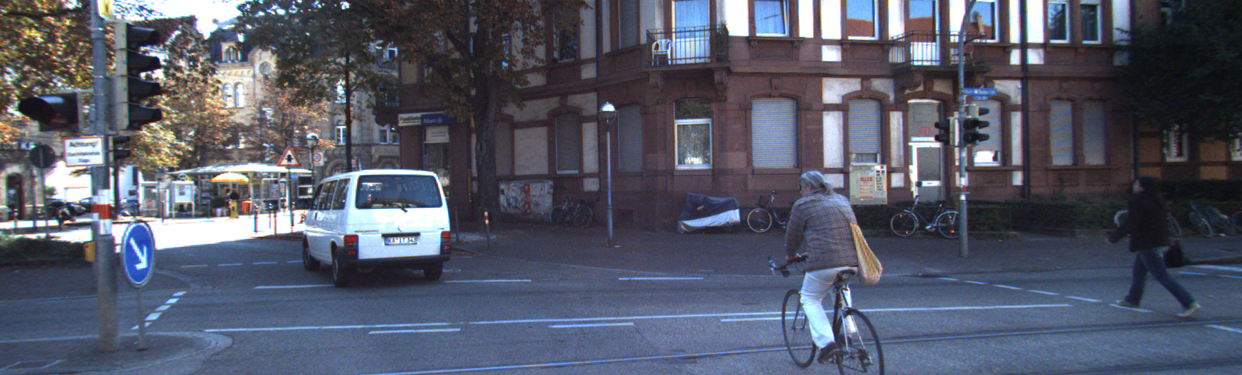

In [7]:
frame

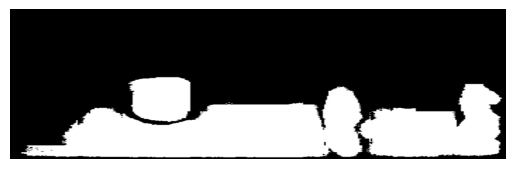

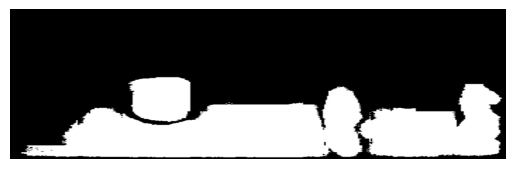

In [8]:
for ret in result:
    plt.imshow(ret, cmap="grey")
    plt.axis("off")
    plt.show()